In [12]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# sklearn libraries 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

In [13]:
# Load the dataset
file_path = '../../../dataset/winequality-red.csv'

try:
    data = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    raise FileNotFoundError(
        f"Dataset not found at: {file_path}\n"
        "Upload the CSV file and update the file_path variable"
    )

Dataset loaded successfully.


In [14]:
# Dataset Explorer

print("\nFirst Five Records: ")
data.head()

# print("\nDataset Dimensions: ")
# print("Rows: ", data.shape[0])
# print("Columns: ", data.shape[1])

# print("\nColumn Names: ")
# data.columns

# print("\nDescriptive Statistics: ")
# data.describe()

# print("\nMissing Values Per Column: ")
# data.isnull().sum()



First Five Records: 


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [15]:
# Data preprocessing
required_columns = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol', 'quality'
]

missing_columns = [
    column for column in required_columns
    if column not in data.columns
]

if missing_columns:
  raise ValueError(
      "The following required columns are missing: "
      + ", ".join(missing_columns)
  )
  
model_data = data[required_columns]

for column in required_columns:
  model_data[column] = pd.to_numeric(
      model_data[column],
      errors='coerce'
  )

rows_before =  len(model_data)
model_data = model_data.dropna().copy().drop_duplicates().reset_index(drop=True)
rows_after = len(model_data)

print('\nData Cleaning')
print('Rows before cleaning: ', rows_before)
print('Rows after cleaning: ', rows_after)
print("Rows removed", rows_before - rows_after)

if len(model_data) < 5:
  raise ValueError(
      "The dataset contains too few valid records to train the model."
  )


Data Cleaning
Rows before cleaning:  1599
Rows after cleaning:  1359
Rows removed 240


In [16]:
# Separate the Features and Target

# Convert original 3-8 quality score into binary classification:
# 1 = Good Quality (Score >= 6)
# 0 = Low Quality  (Score < 6)
model_data['quality_label'] = (model_data['quality'] >= 6).astype(int)


X = model_data[
    [
        'fixed acidity', 'volatile acidity', 'citric acid', 
        'residual sugar', 'chlorides', 'free sulfur dioxide', 
        'total sulfur dioxide', 'density','pH', 'sulphates', 'alcohol', 
    ]
]

y = model_data['quality_label']

print('\nFeatures')
print(X.head())

print('\nTarget')
print(y.head())


Features
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.66         0.00             1.8      0.075   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 13.0                  40.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8  
4      9.4 

In [17]:
# Model Training and Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_proba = rf.predict_proba(X_test)[:, list(rf.classes_).index(1)]
  
print('Train Test Split')
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)
print('y_proba:', y_proba[:5])  

Train Test Split
X_train shape: (1087, 11)
X_test shape: (272, 11)
y_train shape: (1087,)
y_test shape: (272,)
y_proba: [0.33090187 0.24677414 0.69676851 0.26687956 0.78293631]


In [18]:
# # Feature Scaling
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# print('\nFeature Scaling')
# print('X_train_scaled shape:', X_train_scaled.shape)
# print('X_test_scaled shape:', X_test_scaled.shape)

In [19]:
# 5-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = cross_validate(rf, X_train, y_train, cv=cv, scoring=scoring, error_score='raise')

print("=== 5-FOLD CROSS-VALIDATION SUMMARY (TRAINING DATA) ===")
print(f"Validation Accuracy: {cv_results['test_accuracy'].mean():.2%} (+/- {cv_results['test_accuracy'].std():.2%})")
print(f"Validation ROC-AUC:  {cv_results['test_roc_auc'].mean():.2%}")
print(f"Validation Precision:{cv_results['test_precision'].mean():.2%}")
print(f"Validation Recall:   {cv_results['test_recall'].mean():.2%}")
print(f"Validation F1-Score: {cv_results['test_f1'].mean():.2%}\n")

=== 5-FOLD CROSS-VALIDATION SUMMARY (TRAINING DATA) ===
Validation Accuracy: 74.52% (+/- 4.68%)
Validation ROC-AUC:  82.60%
Validation Precision:75.92%
Validation Recall:   76.00%
Validation F1-Score: 75.92%



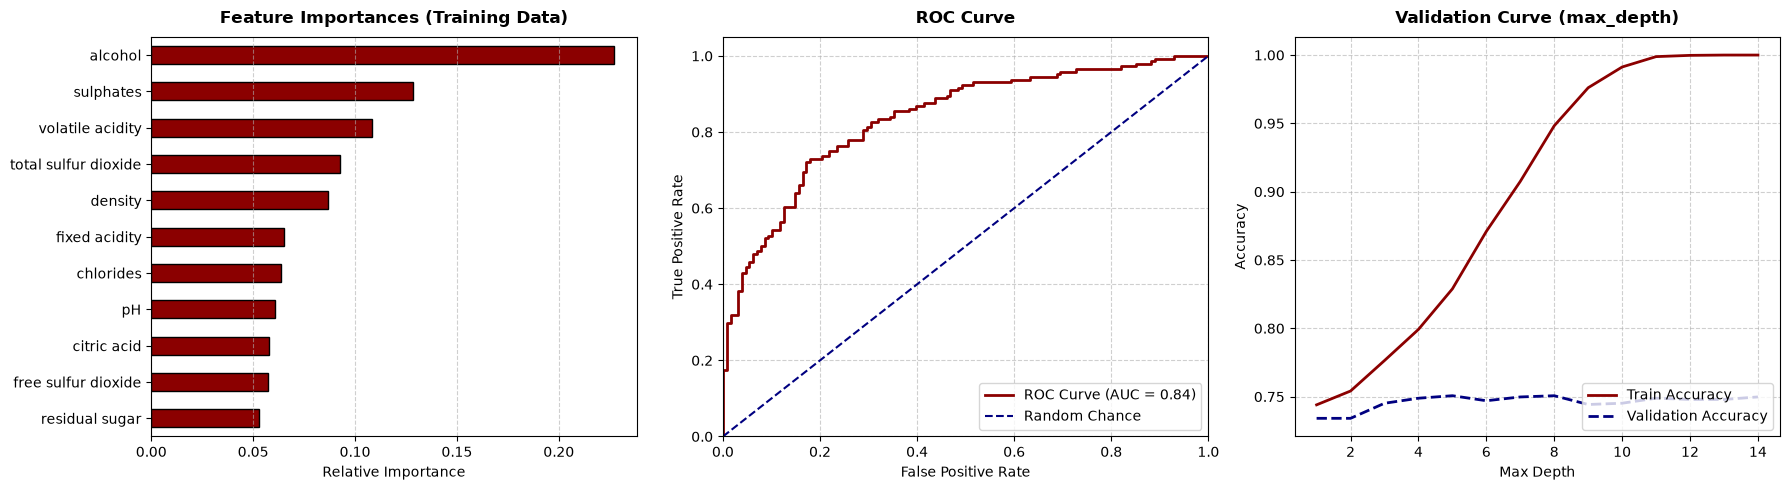

In [20]:
# Visualize the results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Feature Importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[0], color='#8B0000', edgecolor='black')
axes[0].set_title('Feature Importances (Training Data)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Relative Importance')
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#8B0000', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Chance')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold', pad=10)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: Validation Curve (Tuning max_depth)
param_range = np.arange(1, 15)
train_scores, test_scores = validation_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train, y_train, param_name="max_depth", param_range=param_range,
    cv=cv, scoring="accuracy"
)
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

axes[2].plot(param_range, train_mean, label="Train Accuracy", color='#8B0000', lw=2)
axes[2].plot(param_range, test_mean, label="Validation Accuracy", color="navy", lw=2, linestyle="--")
axes[2].set_xlabel("Max Depth")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Validation Curve (max_depth)", fontsize=12, fontweight='bold', pad=10)
axes[2].legend(loc="lower right")
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()